In [1]:
import itertools
import featuretools as ft
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from pandas.core.interchange.dataframe_protocol import DataFrame
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import PowerTransformer
from woodwork.logical_types import Categorical
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import FunctionTransformer
from mlxtend.feature_selection import SequentialFeatureSelector
from imblearn.over_sampling import SMOTE
from  joblib import dump, load

## Загрузка и первичная обработка

In [2]:
df = pd.read_csv("datasets/data.csv")

In [3]:
df

,Patient_Number,Blood_Pressure_Abnormality,Level_of_Hemoglobin,Genetic_Pedigree_Coefficient,Age,BMI,Sex,Pregnancy,Smoking,Physical_activity,salt_content_in_the_diet,alcohol_consumption_per_day,Level_of_Stress,Chronic_kidney_disease,Adrenal_and_thyroid_disorders
0,1,1,11.28,0.90,34,23,1,1.0,0,45961,48071,NaN,2,1,1
1,2,0,9.75,0.23,54,33,1,NaN,0,26106,25333,205.0,3,0,0
2,3,1,10.79,0.91,70,49,0,NaN,0,9995,29465,67.0,2,1,0
3,4,0,11.00,0.43,71,50,0,NaN,0,10635,7439,242.0,1,1,0
4,5,1,14.17,0.83,52,19,0,NaN,0,15619,49644,397.0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,1,10.14,0.02,69,26,1,NaN,1,26118,47568,144.0,3,1,0
1996,1997,1,11.77,1.00,24,45,1,1.0,1,2572,8063,NaN,3,1,1
1997,1998,1,16.91,0.22,18,42,0,NaN,0,14933,24753,NaN,2,1,1
1998,1999,0,11.15,0.72,46,45,1,NaN,1,18157,15275,253.0,3,0,1


In [4]:
df.isnull().sum() / len(df) * 100

Patient_Number                    0.0
Blood_Pressure_Abnormality        0.0
Level_of_Hemoglobin               0.0
Genetic_Pedigree_Coefficient      4.6
Age                               0.0
BMI                               0.0
Sex                               0.0
Pregnancy                        77.9
Smoking                           0.0
Physical_activity                 0.0
salt_content_in_the_diet          0.0
alcohol_consumption_per_day      12.1
Level_of_Stress                   0.0
Chronic_kidney_disease            0.0
Adrenal_and_thyroid_disorders     0.0
dtype: float64

In [5]:
df.Pregnancy.unique()

array([ 1., nan,  0.])

In [6]:
(df.Pregnancy == 0).sum(), (df.Pregnancy == 1).sum()

(np.int64(243), np.int64(199))

In [7]:
df.drop(columns=["Patient_Number", "Pregnancy"], inplace=True)

In [8]:
category_list = ["Blood_Pressure_Abnormality", "Sex",
                 "Smoking", "Level_of_Stress",
                 "Chronic_kidney_disease", "Adrenal_and_thyroid_disorders"
]

for i in category_list:
    uniq = df[i].unique()
    print(f"{i} Unique Values: {len(uniq)}")

Blood_Pressure_Abnormality Unique Values: 2
Sex Unique Values: 2
Smoking Unique Values: 2
Level_of_Stress Unique Values: 3
Chronic_kidney_disease Unique Values: 2
Adrenal_and_thyroid_disorders Unique Values: 2


## Визуализация

In [17]:
p_transformer = PowerTransformer(method="yeo-johnson")
df_norm = pd.DataFrame(p_transformer.fit_transform(df), columns=df.columns)

In [18]:
df_norm

,Blood_Pressure_Abnormality,Level_of_Hemoglobin,Genetic_Pedigree_Coefficient,Age,BMI,Sex,Smoking,Physical_activity,salt_content_in_the_diet,alcohol_consumption_per_day,Level_of_Stress,Chronic_kidney_disease,Adrenal_and_thyroid_disorders
0,1.013086,-0.054946,1.362899,-0.697982,-0.565155,1.008032,-1.019184,1.376348,1.482068,NaN,0.035103,0.990050,1.120175
1,-0.987083,-0.918205,-0.900569,0.475318,0.286759,1.008032,-1.019184,0.141569,0.120014,-0.213489,1.174873,-1.010051,-0.892718
2,1.013086,-0.309251,1.394711,1.320954,1.541708,-0.992032,-1.019184,-1.066164,0.386690,-1.308825,0.035103,0.990050,-0.892718
3,-0.987083,-0.197956,-0.193973,1.371761,1.616845,-0.992032,-1.019184,-1.011331,-1.234934,0.037211,-1.252866,0.990050,-0.892718
4,1.013086,1.137585,1.138826,0.364667,-0.927310,-0.992032,-1.019184,-0.609435,1.568699,0.988703,0.035103,-1.010051,-0.892718
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1.013086,-0.677766,-1.679662,1.269930,-0.302432,1.008032,0.981177,0.142377,1.454204,-0.657659,1.174873,0.990050,-0.892718
1996,1.013086,0.181587,1.678885,-1.360466,1.237701,1.008032,0.981177,-1.805320,-1.178053,NaN,1.174873,0.990050,1.120175
1997,1.013086,1.940593,-0.936741,-1.796914,1.005802,-0.992032,-1.019184,-0.662514,0.081661,NaN,0.035103,0.990050,1.120175
1998,-0.987083,-0.120600,0.781597,0.024799,1.237701,1.008032,0.981177,-0.418051,-0.586939,0.109579,1.174873,-1.010051,1.120175


In [10]:
import pandas as pd
import numpy as np
from scipy.stats import norm

def transform_to_normal(df):
    """
    Преобразует существующие данные DataFrame в нормальное распределение.
    Сохраняет порядок значений: самый маленький элемент останется самым маленьким.
    """
    df_norm = df.copy()

    for col in df_norm.select_dtypes(include=[np.number]).columns:
        # 1. Получаем ранги (позиции) значений (от 1 до N)
        ranks = df_norm[col].rank(method='average')

        # 2. Переводим ранги в диапазон (0, 1) — это дает равномерное распределение
        # (вычитаем 0.5, чтобы избежать 0 и 1, где функция norm.ppf выдает бесконечность)
        uniform_quantiles = (ranks - 0.5) / len(ranks)

        # 3. Применяем функцию квантилей нормального распределения (Inverse CDF)
        # Это превращает равномерные [0, 1] в нормальные (-inf, +inf)
        df_norm[col] = norm.ppf(uniform_quantiles)

    return df_norm

#df_norm = transform_to_normal(df)
df_norm = df.copy()

<Axes: xlabel='salt_content_in_the_diet', ylabel='Count'>

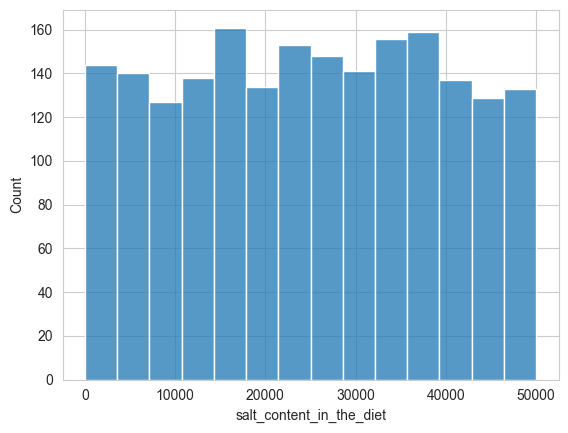

In [12]:
sns.histplot(df_norm, x=df_norm["salt_content_in_the_diet"])

<Axes: xlabel='Physical_activity', ylabel='Count'>

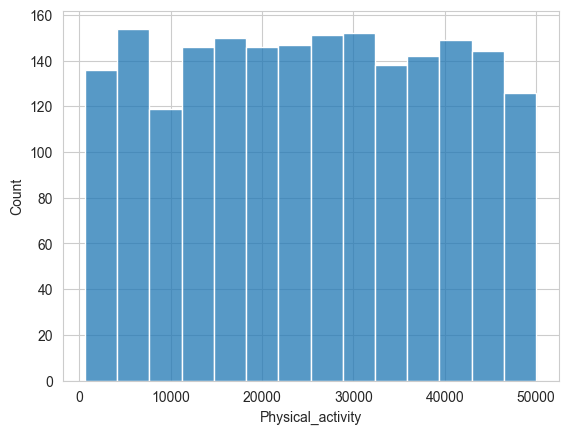

In [13]:
sns.histplot(df_norm, x=df_norm["Physical_activity"])

<Axes: xlabel='BMI', ylabel='Count'>

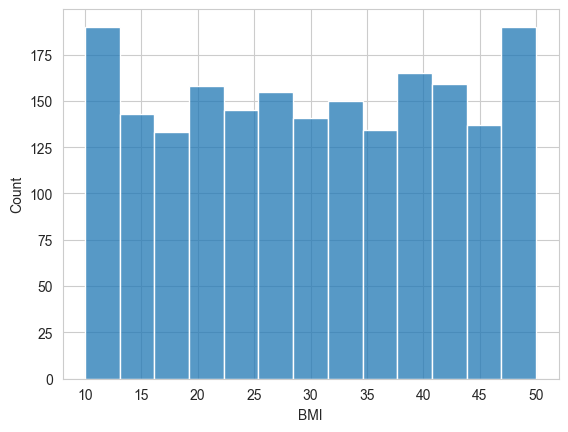

In [14]:
sns.histplot(df_norm, x=df_norm["BMI"])

In [15]:
df_norm.columns

Index(['Blood_Pressure_Abnormality', 'Level_of_Hemoglobin',
       'Genetic_Pedigree_Coefficient', 'Age', 'BMI', 'Sex', 'Smoking',
       'Physical_activity', 'salt_content_in_the_diet',
       'alcohol_consumption_per_day', 'Level_of_Stress',
       'Chronic_kidney_disease', 'Adrenal_and_thyroid_disorders'],
      dtype='object')

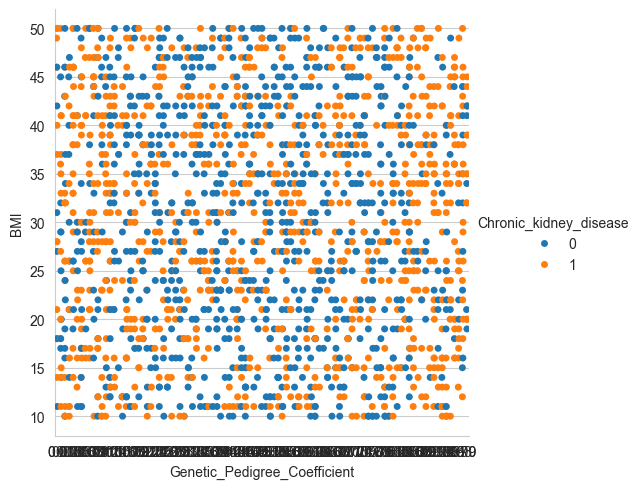

In [12]:
sns.catplot(data=df_norm, x="Genetic_Pedigree_Coefficient", y=df["BMI"], hue="Chronic_kidney_disease")

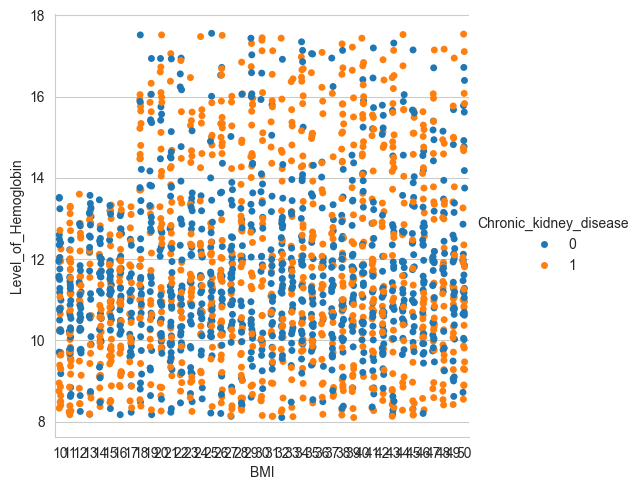

In [13]:
sns.catplot(data=df_norm, x=df["BMI"], y="Level_of_Hemoglobin", hue="Chronic_kidney_disease")

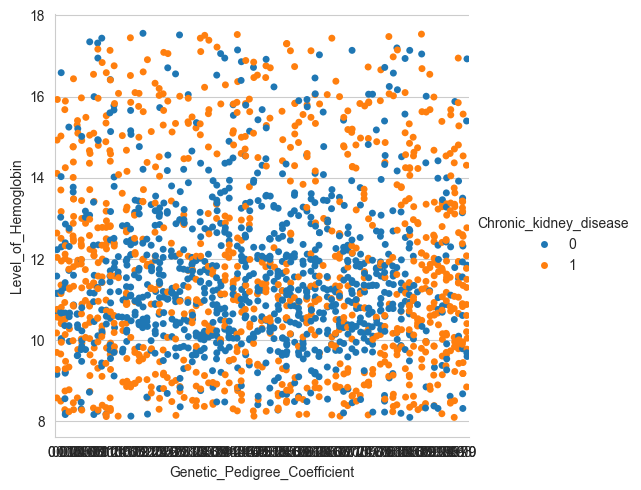

In [14]:
sns.catplot(data=df_norm, x="Genetic_Pedigree_Coefficient", y="Level_of_Hemoglobin", hue="Chronic_kidney_disease")

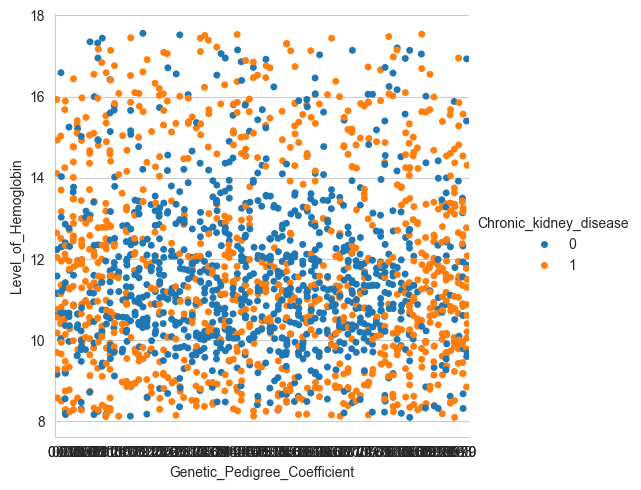

In [15]:
sns.catplot(data=df_norm, x="Genetic_Pedigree_Coefficient", y="Level_of_Hemoglobin", hue="Chronic_kidney_disease")

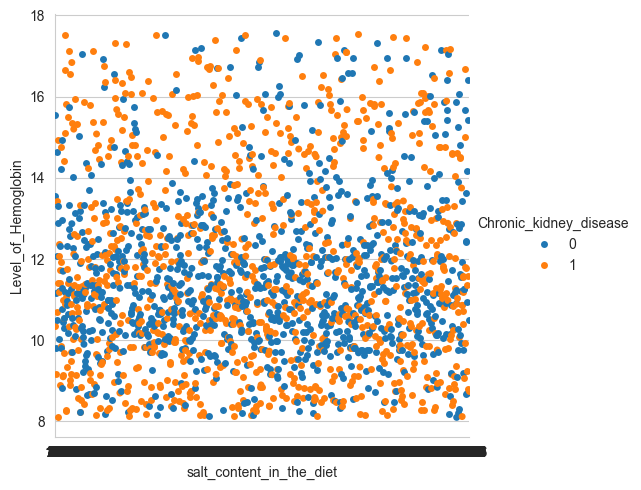

In [16]:
sns.catplot(data=df_norm, x=df["salt_content_in_the_diet"], y="Level_of_Hemoglobin", hue="Chronic_kidney_disease")

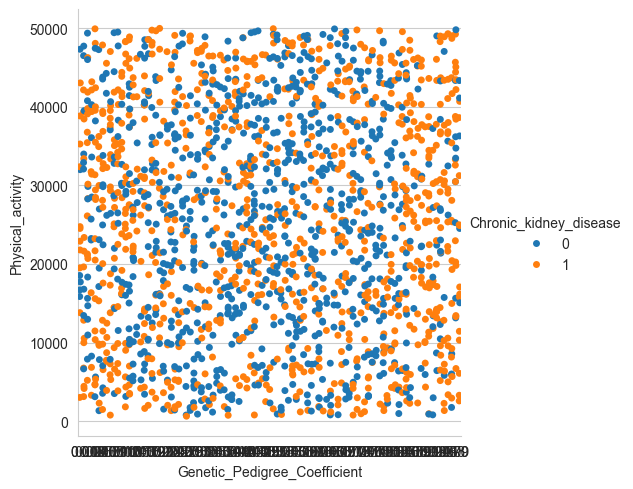

In [17]:
sns.catplot(data=df_norm, x="Genetic_Pedigree_Coefficient", y=df["Physical_activity"], hue="Chronic_kidney_disease")

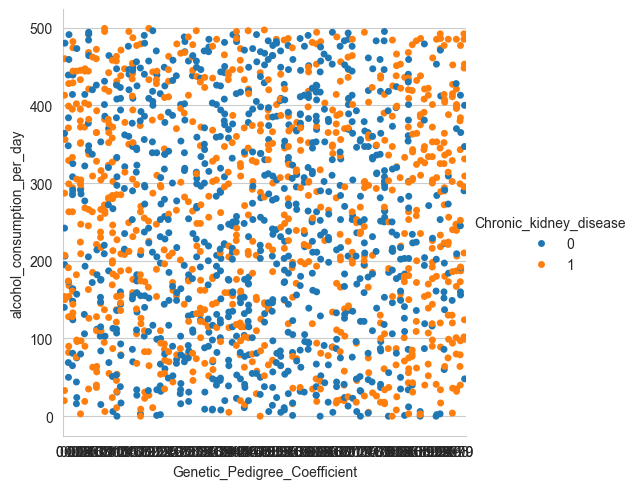

In [18]:
sns.catplot(data=df_norm, x="Genetic_Pedigree_Coefficient", y=df["alcohol_consumption_per_day"], hue="Chronic_kidney_disease")

In [208]:
df.columns

Index(['Blood_Pressure_Abnormality', 'Level_of_Hemoglobin',
       'Genetic_Pedigree_Coefficient', 'Age', 'BMI', 'Sex', 'Smoking',
       'Physical_activity', 'salt_content_in_the_diet',
       'alcohol_consumption_per_day', 'Level_of_Stress',
       'Chronic_kidney_disease', 'Adrenal_and_thyroid_disorders'],
      dtype='object')

In [25]:
df_copy = df.copy()

In [26]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Blood_Pressure_Abnormality     2000 non-null   int64  
 1   Level_of_Hemoglobin            2000 non-null   float64
 2   Genetic_Pedigree_Coefficient   1908 non-null   float64
 3   Age                            2000 non-null   int64  
 4   BMI                            2000 non-null   int64  
 5   Sex                            2000 non-null   int64  
 6   Smoking                        2000 non-null   int64  
 7   Physical_activity              2000 non-null   int64  
 8   salt_content_in_the_diet       2000 non-null   int64  
 9   alcohol_consumption_per_day    1758 non-null   float64
 10  Level_of_Stress                2000 non-null   int64  
 11  Chronic_kidney_disease         2000 non-null   int64  
 12  Adrenal_and_thyroid_disorders  2000 non-null   i

In [21]:
df_copy.isnull().sum() / len(df) * 100

Blood_Pressure_Abnormality        0.0
Level_of_Hemoglobin               0.0
Genetic_Pedigree_Coefficient      4.6
Age                               0.0
BMI                               0.0
Sex                               0.0
Smoking                           0.0
Physical_activity                 0.0
salt_content_in_the_diet          0.0
alcohol_consumption_per_day      12.1
Level_of_Stress                   0.0
Chronic_kidney_disease            0.0
Adrenal_and_thyroid_disorders     0.0
activity_salt                     0.0
salt_alcohol                     12.1
level_smoking                     0.0
salt_bmi                          0.0
alcohol_bmi_divide               12.1
alcohol_bmi_multiplicative       12.1
alcohol_age_divide               12.1
alcohol_age_multiplicative       12.1
blood_alcohol_mult_1000          12.3
salt_age                          0.0
activity_age                      0.0
activity_salt_sex                 0.0
dtype: float64

<Axes: >

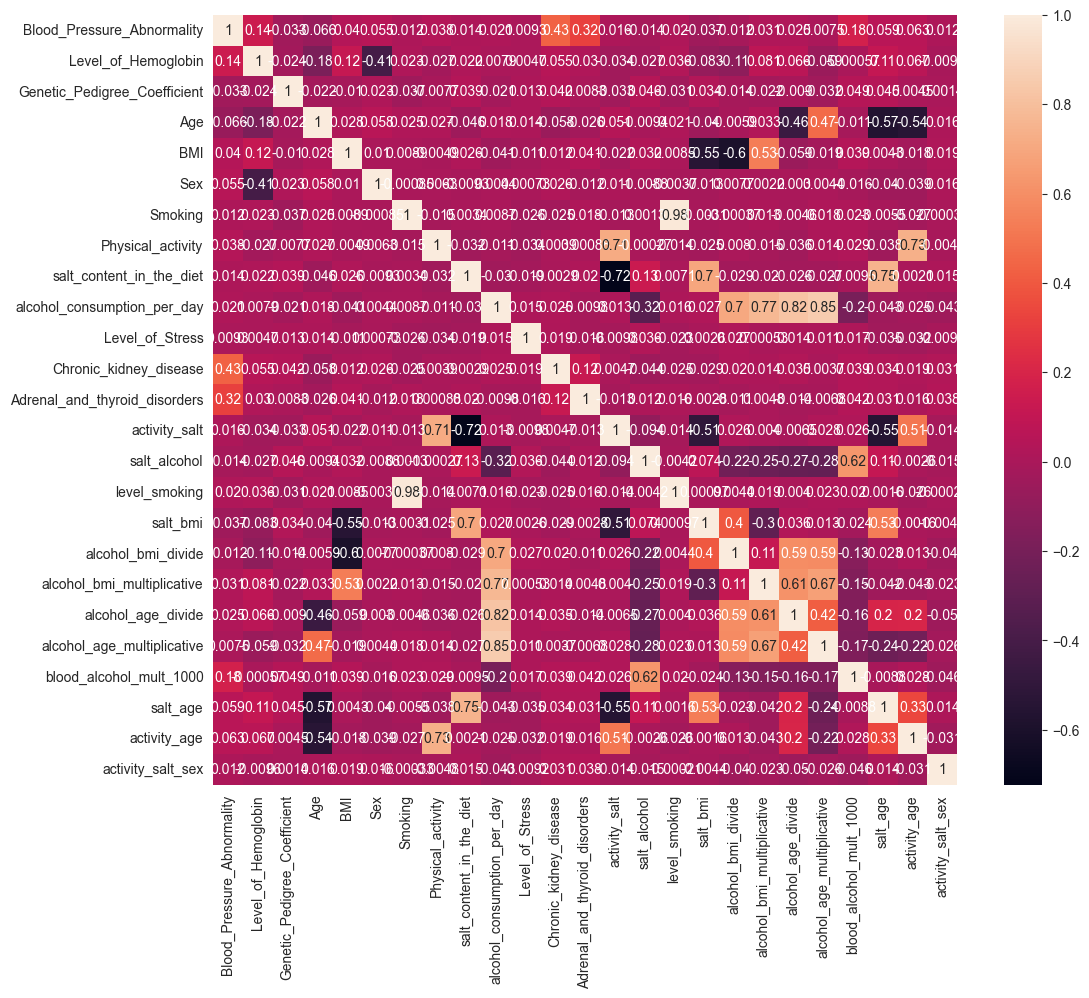

In [22]:
corr_matrix = df_copy.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(data=corr_matrix, annot=True)

## Категоризация признаков

In [9]:
df_copy = df.copy()

In [96]:
def categorize_all(dataframe: pd.DataFrame, categorizable_list: list, splits: int = 3):
    ready_list = []
    choices = []
    for split in range(splits):
        choices.append(split)

    for category in categorizable_list:
        categorizable = dataframe[category]
        min = categorizable.min()
        max = categorizable.max()
        diff = max - min

        conditions = []
        for _ in range(splits):
            conditions.append((categorizable >= min) & (categorizable <= min + diff / splits))
            min += diff / splits
        ready_list.append(np.select(conditions, choices, default=-1))

    return ready_list

In [97]:
df_copy.loc[:, "activity_salt"] = df_copy["Physical_activity"] - df_copy["salt_content_in_the_diet"]
df_copy.loc[:, "salt_alcohol"] = df_copy["salt_content_in_the_diet"] / df_copy["alcohol_consumption_per_day"]
df_copy.loc[:, "level_smoking"] = df_copy["Level_of_Hemoglobin"] * (2 * df_copy["Smoking"] - 1)
df_copy.loc[:, "salt_bmi"] = df_copy["salt_content_in_the_diet"] / df_copy["BMI"]
df_copy.loc[:, "alcohol_bmi_divide"] = df_copy["alcohol_consumption_per_day"] / df_copy["BMI"]
df_copy.loc[:, "alcohol_bmi_multiplicative"] = df_copy["alcohol_consumption_per_day"] * df_copy["BMI"]
df_copy.loc[:, "alcohol_age_divide"] = df_copy["alcohol_consumption_per_day"] / df_copy["Age"]
df_copy.loc[:, "alcohol_age_multiplicative"] = df_copy["alcohol_consumption_per_day"] * df_copy["Age"]
df_copy.loc[:, "blood_alcohol_mult_1000"] = df_copy["Blood_Pressure_Abnormality"] / df_copy["alcohol_consumption_per_day"] * 1000
df_copy.loc[:, "salt_age"] = df_copy["salt_content_in_the_diet"] / df_copy["Age"]
df_copy.loc[:, "activity_age"] = df_copy["Physical_activity"] / df_copy["Age"]
df_copy.loc[:, "activity_salt_sex"] = (df_copy["Physical_activity"] - df_copy["salt_content_in_the_diet"]) * (2 * df_copy["Sex"] - 1)

In [98]:
df_copy.loc[:, "category_GPC"] = categorize_all(df_copy, ["Genetic_Pedigree_Coefficient"], splits=4)[0]

In [167]:
category_list = ["BMI", "Physical_activity", "salt_content_in_the_diet",
                 "alcohol_consumption_per_day"]

ready_list = categorize_all(df, category_list)
for i in range(category_list.__len__()):
    df_copy[f"Category {category_list[i]}"] = ready_list[i]

In [99]:
df_copy.head()

,Blood_Pressure_Abnormality,Level_of_Hemoglobin,Genetic_Pedigree_Coefficient,Age,BMI,Sex,Smoking,Physical_activity,salt_content_in_the_diet,alcohol_consumption_per_day,...,salt_bmi,alcohol_bmi_divide,alcohol_bmi_multiplicative,alcohol_age_divide,alcohol_age_multiplicative,blood_alcohol_mult_1000,salt_age,activity_age,activity_salt_sex,category_GPC
0,1,11.28,0.90,34,23,1,0,45961,48071,NaN,...,2090.043478,NaN,NaN,NaN,NaN,NaN,1413.852941,1351.794118,-2110,3
1,0,9.75,0.23,54,33,1,0,26106,25333,205.0,...,767.666667,6.212121,6765.0,3.796296,11070.0,0.000000,469.129630,483.444444,773,0
2,1,10.79,0.91,70,49,0,0,9995,29465,67.0,...,601.326531,1.367347,3283.0,0.957143,4690.0,14.925373,420.928571,142.785714,19470,3
3,0,11.00,0.43,71,50,0,0,10635,7439,242.0,...,148.780000,4.840000,12100.0,3.408451,17182.0,0.000000,104.774648,149.788732,-3196,1
4,1,14.17,0.83,52,19,0,0,15619,49644,397.0,...,2612.842105,20.894737,7543.0,7.634615,20644.0,2.518892,954.692308,300.365385,34025,3


In [169]:
def CategorizeBMI(df):
    categorizable = df["BMI"]

    conditions = [
        (categorizable < 16),
        categorizable.between(16, 18.444),
        categorizable.between(18.5, 24.999),
        categorizable.between(25, 29.999),
        categorizable.between(30, 34.999),
        categorizable.between(35, 39.999),
        categorizable > 40
                  ]

    choices = [
        "Очень низкий BMI",
        "Низкий BMI",
        "Обычный BMI",
        "Повышенный BMI",
        "Высокий BMI",
        "Очень высокий BMI",
        "Чрезвычайно высокий BMI"
              ]

    return np.select(conditions, choices, default = "Не определён")

In [136]:
df_copy["Category BMI"] = CategorizeBMI(df_copy)

In [170]:
df_copy.drop(columns=category_list, inplace=True)

In [10]:
df_copy

,Blood_Pressure_Abnormality,Level_of_Hemoglobin,Genetic_Pedigree_Coefficient,Age,BMI,Sex,Smoking,Physical_activity,salt_content_in_the_diet,alcohol_consumption_per_day,Level_of_Stress,Chronic_kidney_disease,Adrenal_and_thyroid_disorders
0,1,11.28,0.90,34,23,1,0,45961,48071,NaN,2,1,1
1,0,9.75,0.23,54,33,1,0,26106,25333,205.0,3,0,0
2,1,10.79,0.91,70,49,0,0,9995,29465,67.0,2,1,0
3,0,11.00,0.43,71,50,0,0,10635,7439,242.0,1,1,0
4,1,14.17,0.83,52,19,0,0,15619,49644,397.0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1,10.14,0.02,69,26,1,1,26118,47568,144.0,3,1,0
1996,1,11.77,1.00,24,45,1,1,2572,8063,NaN,3,1,1
1997,1,16.91,0.22,18,42,0,0,14933,24753,NaN,2,1,1
1998,0,11.15,0.72,46,45,1,1,18157,15275,253.0,3,0,1


## Создание модели

In [100]:
df_copy.loc[:, "minus_log_bmi"] = -np.log2(df_copy["BMI"])
df_copy.loc[:, "gpc_multi_hemoglobin"] = df_copy["Genetic_Pedigree_Coefficient"] * df["Level_of_Hemoglobin"]
df_copy.loc[:, "gpc_multi_hemoglobin_abnormal"] = df_copy["gpc_multi_hemoglobin"] * (2 * df_copy["Blood_Pressure_Abnormality"] - 1)
df_copy.loc[:, "minus_activity_sqrt"] = -df_copy["Physical_activity"]**(1/2)
df_copy.loc[:, "minus_alcohol_sqrt"] = -df_copy["alcohol_consumption_per_day"]**(1/2)
df_copy.loc[:, "minus_alcohol_sqrt_abnormal"] = df_copy["minus_alcohol_sqrt"] * (2 * df_copy["Blood_Pressure_Abnormality"] - 1)

In [24]:
df_copy

,Blood_Pressure_Abnormality,Level_of_Hemoglobin,Genetic_Pedigree_Coefficient,Age,BMI,Sex,Smoking,Physical_activity,salt_content_in_the_diet,alcohol_consumption_per_day,Level_of_Stress,Chronic_kidney_disease,Adrenal_and_thyroid_disorders
0,1,11.28,0.90,34,23,1,0,45961,48071,NaN,2,1,1
1,0,9.75,0.23,54,33,1,0,26106,25333,205.0,3,0,0
2,1,10.79,0.91,70,49,0,0,9995,29465,67.0,2,1,0
3,0,11.00,0.43,71,50,0,0,10635,7439,242.0,1,1,0
4,1,14.17,0.83,52,19,0,0,15619,49644,397.0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1,10.14,0.02,69,26,1,1,26118,47568,144.0,3,1,0
1996,1,11.77,1.00,24,45,1,1,2572,8063,NaN,3,1,1
1997,1,16.91,0.22,18,42,0,0,14933,24753,NaN,2,1,1
1998,0,11.15,0.72,46,45,1,1,18157,15275,253.0,3,0,1


In [25]:
X = pd.DataFrame(df_copy)
#X.drop(columns=["BMI", "Physical_activity", "alcohol_consumption_per_day", "Chronic_kidney_disease"], inplace=True)
X.drop(columns=["Chronic_kidney_disease", "Adrenal_and_thyroid_disorders"], inplace=True)
#y = pd.DataFrame(df_copy[["Chronic_kidney_disease", "Adrenal_and_thyroid_disorders"]])
y = pd.DataFrame(df_copy["Chronic_kidney_disease"])

In [26]:
X = X.astype("float32")

In [27]:
y

,Chronic_kidney_disease
0,1
1,0
2,1
3,1
4,0
...,...
1995,1
1996,1
1997,1
1998,0


In [28]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Blood_Pressure_Abnormality    2000 non-null   float32
 1   Level_of_Hemoglobin           2000 non-null   float32
 2   Genetic_Pedigree_Coefficient  1908 non-null   float32
 3   Age                           2000 non-null   float32
 4   BMI                           2000 non-null   float32
 5   Sex                           2000 non-null   float32
 6   Smoking                       2000 non-null   float32
 7   Physical_activity             2000 non-null   float32
 8   salt_content_in_the_diet      2000 non-null   float32
 9   alcohol_consumption_per_day   1758 non-null   float32
 10  Level_of_Stress               2000 non-null   float32
dtypes: float32(11)
memory usage: 86.1 KB


In [332]:
(y["Chronic_kidney_disease"] == 0).sum(), (y["Adrenal_and_thyroid_disorders"] == 0).sum()

(np.int64(990), np.int64(1113))

In [109]:
float_columns = X.select_dtypes(include="float64").columns

X[float_columns] = X[float_columns].astype("float32")

X.replace([np.inf, -np.inf], [0, 1], inplace=True)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
X_train

,Blood_Pressure_Abnormality,Level_of_Hemoglobin,Genetic_Pedigree_Coefficient,Age,BMI,Sex,Smoking,Physical_activity,salt_content_in_the_diet,alcohol_consumption_per_day,Level_of_Stress
1140,1.0,8.18,0.61,52.0,36.0,1.0,1.0,30556.0,36554.0,398.0,2.0
1442,0.0,10.45,0.29,46.0,47.0,1.0,1.0,11339.0,35221.0,16.0,3.0
1701,0.0,12.05,NaN,64.0,14.0,1.0,0.0,22344.0,26606.0,144.0,2.0
75,1.0,15.68,0.91,31.0,44.0,0.0,0.0,10122.0,33321.0,422.0,1.0
55,0.0,10.93,0.35,52.0,23.0,1.0,1.0,38891.0,22869.0,68.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
1048,1.0,15.85,0.98,67.0,18.0,0.0,1.0,19298.0,28140.0,239.0,2.0
992,0.0,10.07,0.97,34.0,46.0,1.0,0.0,10563.0,25631.0,302.0,1.0
1904,1.0,9.34,0.89,54.0,38.0,1.0,1.0,20355.0,1416.0,329.0,2.0
1490,1.0,14.52,0.61,42.0,37.0,0.0,1.0,6380.0,48714.0,284.0,1.0


In [31]:
y_train

,Chronic_kidney_disease
1140,1
1442,0
1701,0
75,1
55,1
...,...
1048,1
992,1
1904,1
1490,1


In [32]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("rf", RandomForestClassifier(random_state=42))
])

params_grid = {
    "rf__n_estimators": list(range(1, 100)),
    "rf__max_depth": list(range(1, 20)),
    "rf__min_samples_leaf": [1, 2],
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train["Chronic_kidney_disease"].to_numpy().ravel())

print(f"Best score: {grid_search.best_score_}")

C:\Users\romeow\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best score: 0.7294394044891617


In [33]:
grid_search.best_params_

{'rf__max_depth': 7, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 36}

In [34]:
y_predictions = grid_search.best_estimator_.predict(X_test)

In [35]:
cnf_matrix = confusion_matrix(y_test["Chronic_kidney_disease"].to_numpy().ravel(), y_predictions)

In [36]:
def plot_confusion_matrix(cm, classes,
                          normalize = False,
                          title = "Confusion matrix",
                          cmap = plt.get_cmap("Blues")):
    plt.imshow(cm, interpolation = "nearest", cmap = cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation = 45)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype(float) / cm.sum(axis = 1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")
    print(cm)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment = "center",
                 color = "white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

Confusion matrix, without normalization
[[139  59]
 [ 62 140]]


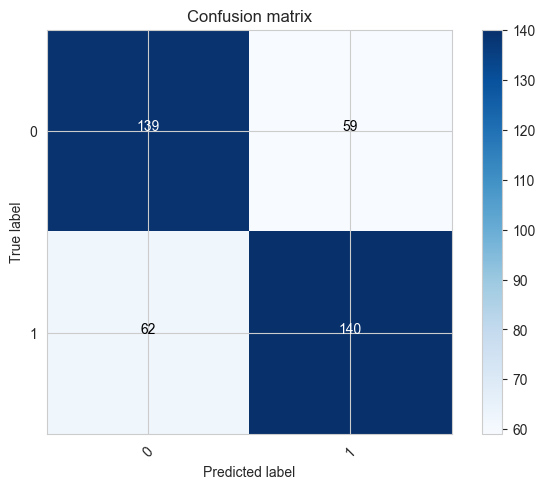

In [37]:
plot_confusion_matrix(cnf_matrix, classes = ["0", "1"], title = "Confusion matrix")

First try: Best score: 0.7181309707033592, {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 66}, splits=3

Second try: Best score: 0.7152087476610418, {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 99}, splits=5

Third try: Best score: 0.7174311696576473, {'max_depth': 8, 'min_samples_leaf': 4, 'n_estimators': 72}, splits=5

Fourth try: Best score: 0.7170656415112123, {'max_depth': 13, 'min_samples_leaf': 4, 'n_estimators': 136}, splits=7

Fifth try: Best score: 0.7187020647556052, {'max_depth': 14, 'min_samples_leaf': 4, 'n_estimators': 51}, splits=3

without split
Best score: 0.715772316416986, {'max_depth': 4, 'min_samples_leaf': 4, 'n_estimators': 22}

without split in level hem and coef
Best score: 0.7150771465660055, {'max_depth': 4, 'min_samples_leaf': 4, 'n_estimators': 22} split=3


## С отбором признаков

In [35]:
df_copy

,Blood_Pressure_Abnormality,Level_of_Hemoglobin,Genetic_Pedigree_Coefficient,Age,BMI,Sex,Smoking,Physical_activity,salt_content_in_the_diet,alcohol_consumption_per_day,...,salt_age,activity_age,activity_salt_sex,category_GPC,minus_log_bmi,gpc_multi_hemoglobin,gpc_multi_hemoglobin_abnormal,minus_activity_sqrt,minus_alcohol_sqrt,minus_alcohol_sqrt_abnormal
0,1,11.28,0.90,34,23,1,0,45961,48071,NaN,...,1413.852941,1351.794118,-2110,Split 3,-4.523562,10.1520,10.1520,-214.385167,NaN,NaN
1,0,9.75,0.23,54,33,1,0,26106,25333,205.0,...,469.129630,483.444444,773,Split 0,-5.044394,2.2425,-2.2425,-161.573513,-14.317821,14.317821
2,1,10.79,0.91,70,49,0,0,9995,29465,67.0,...,420.928571,142.785714,19470,Split 3,-5.614710,9.8189,9.8189,-99.974997,-8.185353,-8.185353
3,0,11.00,0.43,71,50,0,0,10635,7439,242.0,...,104.774648,149.788732,-3196,Split 1,-5.643856,4.7300,-4.7300,-103.126136,-15.556349,15.556349
4,1,14.17,0.83,52,19,0,0,15619,49644,397.0,...,954.692308,300.365385,34025,Split 3,-4.247928,11.7611,11.7611,-124.975998,-19.924859,-19.924859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1,10.14,0.02,69,26,1,1,26118,47568,144.0,...,689.391304,378.521739,-21450,Split 0,-4.700440,0.2028,0.2028,-161.610643,-12.000000,-12.000000
1996,1,11.77,1.00,24,45,1,1,2572,8063,NaN,...,335.958333,107.166667,-5491,Split 3,-5.491853,11.7700,11.7700,-50.714889,NaN,NaN
1997,1,16.91,0.22,18,42,0,0,14933,24753,NaN,...,1375.166667,829.611111,9820,Split 0,-5.392317,3.7202,3.7202,-122.200655,NaN,NaN
1998,0,11.15,0.72,46,45,1,1,18157,15275,253.0,...,332.065217,394.717391,2882,Split 2,-5.491853,8.0280,-8.0280,-134.747913,-15.905974,15.905974


In [36]:
es = ft.EntitySet(id = "patients")
es.add_dataframe(dataframe_name="patients_es",
                 dataframe=df_copy,
                 make_index=True,
                 index="index",
                 logical_types={"Blood_Pressure_Abnormality": Categorical, "Sex": Categorical,
                                "Smoking": Categorical, "Level_of_Stress": Categorical,
                                "category_GPC": Categorical})

Entityset: patients
  DataFrames:
    patients_es [Rows: 2000, Columns: 33]
  Relationships:
    No relationships

In [37]:
es["patients_es"].ww.schema

,Logical Type,Semantic Tag(s)
Column,,
index,Integer,['index']
Blood_Pressure_Abnormality,Categorical,['category']
Level_of_Hemoglobin,Double,['numeric']
Genetic_Pedigree_Coefficient,Double,['numeric']
Age,Integer,['numeric']
BMI,Integer,['numeric']
Sex,Categorical,['category']
Smoking,Categorical,['category']
Physical_activity,Integer,['numeric']


In [38]:
es.normalize_dataframe(base_dataframe_name="patients_es",
                       new_dataframe_name="abnormality_es",
                       index="Blood_Pressure_Abnormality")
es.normalize_dataframe(base_dataframe_name="patients_es",
                       new_dataframe_name="sex_es",
                       index="Sex")
es.normalize_dataframe(base_dataframe_name="patients_es",
                       new_dataframe_name="smoking_es",
                       index="Smoking")
es.normalize_dataframe(base_dataframe_name="patients_es",
                       new_dataframe_name="stress_es",
                       index="Level_of_Stress")
es.normalize_dataframe(base_dataframe_name="patients_es",
                       new_dataframe_name="GPC_es",
                       index="category_GPC")

Entityset: patients
  DataFrames:
    patients_es [Rows: 2000, Columns: 33]
    abnormality_es [Rows: 2, Columns: 1]
    sex_es [Rows: 2, Columns: 1]
    smoking_es [Rows: 2, Columns: 1]
    stress_es [Rows: 3, Columns: 1]
    GPC_es [Rows: 5, Columns: 1]
  Relationships:
    patients_es.Blood_Pressure_Abnormality -> abnormality_es.Blood_Pressure_Abnormality
    patients_es.Sex -> sex_es.Sex
    patients_es.Smoking -> smoking_es.Smoking
    patients_es.Level_of_Stress -> stress_es.Level_of_Stress
    patients_es.category_GPC -> GPC_es.category_GPC

In [39]:
features, feature_names = ft.dfs(entityset=es, target_dataframe_name="patients_es",
                                 max_depth=2)

C:\Users\romeow\AppData\Local\Programs\Python\Python312\Lib\site-packages\featuretools\computational_backends\feature_set_calculator.py:785: FutureWarning: The provided callable <function min at 0x00000199BE90B9C0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  ).agg(to_agg)
C:\Users\romeow\AppData\Local\Programs\Python\Python312\Lib\site-packages\featuretools\computational_backends\feature_set_calculator.py:785: FutureWarning: The provided callable <function std at 0x00000199BE924400> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  ).agg(to_agg)
C:\Users\romeow\AppData\Local\Programs\Python\Python312\Lib\site-packages\featuretools\computational_backends\feature_set_calculator.py:785: FutureWarning: The provided callable <function mean at 0x

In [40]:
features

,Blood_Pressure_Abnormality,Level_of_Hemoglobin,Genetic_Pedigree_Coefficient,Age,BMI,Sex,Smoking,Physical_activity,salt_content_in_the_diet,alcohol_consumption_per_day,...,GPC_es.SUM(patients_es.gpc_multi_hemoglobin_abnormal),GPC_es.SUM(patients_es.level_smoking),GPC_es.SUM(patients_es.minus_activity_sqrt),GPC_es.SUM(patients_es.minus_alcohol_sqrt),GPC_es.SUM(patients_es.minus_alcohol_sqrt_abnormal),GPC_es.SUM(patients_es.minus_log_bmi),GPC_es.SUM(patients_es.salt_age),GPC_es.SUM(patients_es.salt_alcohol),GPC_es.SUM(patients_es.salt_bmi),GPC_es.SUM(patients_es.salt_content_in_the_diet)
index,,,,,,,,,,,,,,,,,,,,,
0,1,11.28,0.90,34,23,1,0,45961,48071,<NA>,...,2207.2289,-174.49,-67450.291503,-5823.850005,-2370.484673,-2159.330821,305551.922979,inf,471769.649756,11735401.0
1,0,9.75,0.23,54,33,1,0,26106,25333,205,...,112.2629,415.99,-76370.248973,-6762.267296,-2690.268539,-2421.277730,313090.169615,inf,487424.725830,12431201.0
2,1,10.79,0.91,70,49,0,0,9995,29465,67,...,2207.2289,-174.49,-67450.291503,-5823.850005,-2370.484673,-2159.330821,305551.922979,inf,471769.649756,11735401.0
3,0,11.00,0.43,71,50,0,0,10635,7439,242,...,-809.9192,297.79,-70224.659752,-6065.190383,2675.535675,-2239.291488,291494.787518,inf,456878.066640,11312832.0
4,1,14.17,0.83,52,19,0,0,15619,49644,397,...,2207.2289,-174.49,-67450.291503,-5823.850005,-2370.484673,-2159.330821,305551.922979,inf,471769.649756,11735401.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1,10.14,0.02,69,26,1,1,26118,47568,144,...,112.2629,415.99,-76370.248973,-6762.267296,-2690.268539,-2421.277730,313090.169615,inf,487424.725830,12431201.0
1996,1,11.77,1.00,24,45,1,1,2572,8063,<NA>,...,2207.2289,-174.49,-67450.291503,-5823.850005,-2370.484673,-2159.330821,305551.922979,inf,471769.649756,11735401.0
1997,1,16.91,0.22,18,42,0,0,14933,24753,<NA>,...,112.2629,415.99,-76370.248973,-6762.267296,-2690.268539,-2421.277730,313090.169615,inf,487424.725830,12431201.0


In [41]:
from featuretools.selection import (
    remove_highly_correlated_features,
    remove_highly_null_features,
    remove_single_value_features
)

In [42]:
fm_filtered = remove_highly_null_features(features)

fm_filtered = remove_single_value_features(fm_filtered)

fm_filtered, new_features = remove_highly_correlated_features(fm_filtered, feature_names)

C:\Users\romeow\AppData\Local\Programs\Python\Python312\Lib\site-packages\woodwork\type_sys\utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
C:\Users\romeow\AppData\Local\Programs\Python\Python312\Lib\site-packages\woodwork\type_sys\utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
C:\Users\romeow\AppData\Local\Programs\Python\Python312\Lib\site-packages\woodwork\type_sys\utils.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(
C:\Users\romeow\AppData\Local\Programs\Python\Python312\Lib\site-packages\woodw

In [43]:
fm_filtered

,Blood_Pressure_Abnormality,Level_of_Hemoglobin,Genetic_Pedigree_Coefficient,Age,BMI,Sex,Smoking,Physical_activity,salt_content_in_the_diet,alcohol_consumption_per_day,...,GPC_es.MIN(patients_es.salt_bmi),GPC_es.MODE(patients_es.Blood_Pressure_Abnormality),GPC_es.MODE(patients_es.Level_of_Stress),GPC_es.MODE(patients_es.Sex),GPC_es.MODE(patients_es.Smoking),GPC_es.SKEW(patients_es.Level_of_Hemoglobin),GPC_es.SKEW(patients_es.activity_age),GPC_es.SKEW(patients_es.alcohol_age_divide),GPC_es.SKEW(patients_es.alcohol_bmi_multiplicative),GPC_es.SUM(patients_es.salt_alcohol)
index,,,,,,,,,,,,,,,,,,,,,
0,1,11.28,0.90,34,23,1,0,45961,48071,<NA>,...,1.183673,1,3,1,0,0.661491,1.202347,0.866578,0.770299,inf
1,0,9.75,0.23,54,33,1,0,26106,25333,205,...,0.709677,1,3,0,1,0.585027,1.235249,0.984074,0.808584,inf
2,1,10.79,0.91,70,49,0,0,9995,29465,67,...,1.183673,1,3,1,0,0.661491,1.202347,0.866578,0.770299,inf
3,0,11.00,0.43,71,50,0,0,10635,7439,242,...,1.047619,0,1,1,1,0.670494,1.117659,0.937978,1.024594,inf
4,1,14.17,0.83,52,19,0,0,15619,49644,397,...,1.183673,1,3,1,0,0.661491,1.202347,0.866578,0.770299,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1,10.14,0.02,69,26,1,1,26118,47568,144,...,0.709677,1,3,0,1,0.585027,1.235249,0.984074,0.808584,inf
1996,1,11.77,1.00,24,45,1,1,2572,8063,<NA>,...,1.183673,1,3,1,0,0.661491,1.202347,0.866578,0.770299,inf
1997,1,16.91,0.22,18,42,0,0,14933,24753,<NA>,...,0.709677,1,3,0,1,0.585027,1.235249,0.984074,0.808584,inf


In [44]:
X_encoded = pd.get_dummies(fm_filtered, drop_first=True)

#X_clean = X_encoded.fillna(0)

In [45]:
X_clean = X_encoded

In [46]:
X_clean

,Level_of_Hemoglobin,Genetic_Pedigree_Coefficient,Age,BMI,Physical_activity,salt_content_in_the_diet,alcohol_consumption_per_day,Chronic_kidney_disease,Adrenal_and_thyroid_disorders,activity_salt,...,stress_es.MODE(patients_es.Smoking)_1,stress_es.MODE(patients_es.category_GPC)_Split 1,stress_es.MODE(patients_es.category_GPC)_Split 2,stress_es.MODE(patients_es.category_GPC)_Split 3,stress_es.MODE(patients_es.category_GPC)_undefined,GPC_es.MODE(patients_es.Blood_Pressure_Abnormality)_1,GPC_es.MODE(patients_es.Level_of_Stress)_2,GPC_es.MODE(patients_es.Level_of_Stress)_3,GPC_es.MODE(patients_es.Sex)_1,GPC_es.MODE(patients_es.Smoking)_1
index,,,,,,,,,,,,,,,,,,,,,
0,11.28,0.90,34,23,45961,48071,<NA>,1,1,-2110,...,False,False,False,False,False,True,False,True,True,False
1,9.75,0.23,54,33,26106,25333,205,0,0,773,...,True,False,False,False,False,True,False,True,False,True
2,10.79,0.91,70,49,9995,29465,67,1,0,-19470,...,False,False,False,False,False,True,False,True,True,False
3,11.00,0.43,71,50,10635,7439,242,1,0,3196,...,True,False,True,False,False,False,False,False,True,True
4,14.17,0.83,52,19,15619,49644,397,0,0,-34025,...,False,False,False,False,False,True,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,10.14,0.02,69,26,26118,47568,144,1,0,-21450,...,True,False,False,False,False,True,False,True,False,True
1996,11.77,1.00,24,45,2572,8063,<NA>,1,1,-5491,...,True,False,False,False,False,True,False,True,True,False
1997,16.91,0.22,18,42,14933,24753,<NA>,1,1,-9820,...,False,False,False,False,False,True,False,True,False,True


In [112]:
y = pd.DataFrame(df_copy[["Chronic_kidney_disease", "Adrenal_and_thyroid_disorders"]])

In [47]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [48]:
X_clean.columns, len(X_clean.columns)

(Index(['Level_of_Hemoglobin', 'Genetic_Pedigree_Coefficient', 'Age', 'BMI',
        'Physical_activity', 'salt_content_in_the_diet',
        'alcohol_consumption_per_day', 'Chronic_kidney_disease',
        'Adrenal_and_thyroid_disorders', 'activity_salt',
        ...
        'stress_es.MODE(patients_es.Smoking)_1',
        'stress_es.MODE(patients_es.category_GPC)_Split 1',
        'stress_es.MODE(patients_es.category_GPC)_Split 2',
        'stress_es.MODE(patients_es.category_GPC)_Split 3',
        'stress_es.MODE(patients_es.category_GPC)_undefined',
        'GPC_es.MODE(patients_es.Blood_Pressure_Abnormality)_1',
        'GPC_es.MODE(patients_es.Level_of_Stress)_2',
        'GPC_es.MODE(patients_es.Level_of_Stress)_3',
        'GPC_es.MODE(patients_es.Sex)_1', 'GPC_es.MODE(patients_es.Smoking)_1'],
       dtype='object', length=110),
 110)

In [49]:
X_columns = list(X_clean.columns)
del X_columns[8]
del X_columns[7]
X_columns, len(X_columns)

(['Level_of_Hemoglobin',
  'Genetic_Pedigree_Coefficient',
  'Age',
  'BMI',
  'Physical_activity',
  'salt_content_in_the_diet',
  'alcohol_consumption_per_day',
  'activity_salt',
  'salt_alcohol',
  'level_smoking',
  'salt_bmi',
  'alcohol_bmi_divide',
  'alcohol_bmi_multiplicative',
  'alcohol_age_divide',
  'alcohol_age_multiplicative',
  'blood_alcohol_mult_1000',
  'salt_age',
  'activity_age',
  'activity_salt_sex',
  'gpc_multi_hemoglobin',
  'gpc_multi_hemoglobin_abnormal',
  'minus_alcohol_sqrt_abnormal',
  'abnormality_es.COUNT(patients_es)',
  'abnormality_es.MAX(patients_es.blood_alcohol_mult_1000)',
  'abnormality_es.MEAN(patients_es.blood_alcohol_mult_1000)',
  'abnormality_es.SUM(patients_es.blood_alcohol_mult_1000)',
  'sex_es.COUNT(patients_es)',
  'stress_es.COUNT(patients_es)',
  'stress_es.MAX(patients_es.Level_of_Hemoglobin)',
  'stress_es.MAX(patients_es.activity_age)',
  'stress_es.MAX(patients_es.alcohol_age_multiplicative)',
  'stress_es.MAX(patients_es.bloo

In [50]:
y = df["Chronic_kidney_disease"]
y

0       1
1       0
2       1
3       1
4       0
       ..
1995    1
1996    1
1997    1
1998    0
1999    1
Name: Chronic_kidney_disease, Length: 2000, dtype: int64

In [55]:
float_columns = X_clean.select_dtypes(include="float64").columns

X_clean[float_columns] = X_clean[float_columns].astype("float32")

X_clean.replace([np.inf, -np.inf], [0, 1], inplace=True)

In [56]:
X_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 1999
Columns: 110 entries, Level_of_Hemoglobin to GPC_es.MODE(patients_es.Smoking)_1
dtypes: Int64(3), bool(37), float32(58), int64(12)
memory usage: 781.2 KB


In [57]:
imputer = SimpleImputer(strategy="median", add_indicator=True)
imputer.fit(X_clean[X_columns])
X_imputed = imputer.fit_transform(X_clean)
new_column_names = imputer.get_feature_names_out()

X_clean = pd.DataFrame(X_imputed, columns=new_column_names)
X_clean.drop(columns=["Chronic_kidney_disease", "Adrenal_and_thyroid_disorders"], inplace=True)

In [58]:
X_clean

,Level_of_Hemoglobin,Genetic_Pedigree_Coefficient,Age,BMI,Physical_activity,salt_content_in_the_diet,alcohol_consumption_per_day,activity_salt,salt_alcohol,level_smoking,...,missingindicator_alcohol_consumption_per_day,missingindicator_salt_alcohol,missingindicator_alcohol_bmi_divide,missingindicator_alcohol_bmi_multiplicative,missingindicator_alcohol_age_divide,missingindicator_alcohol_age_multiplicative,missingindicator_blood_alcohol_mult_1000,missingindicator_gpc_multi_hemoglobin,missingindicator_gpc_multi_hemoglobin_abnormal,missingindicator_minus_alcohol_sqrt_abnormal
0,11.28,0.90,34.0,23.0,45961.0,48071.0,250.0,-2110.0,99.145115,-11.28,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
1,9.75,0.23,54.0,33.0,26106.0,25333.0,205.0,773.0,123.575607,-9.75,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10.79,0.91,70.0,49.0,9995.0,29465.0,67.0,-19470.0,439.776123,-10.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,11.00,0.43,71.0,50.0,10635.0,7439.0,242.0,3196.0,30.739670,-11.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,14.17,0.83,52.0,19.0,15619.0,49644.0,397.0,-34025.0,125.047859,-14.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,10.14,0.02,69.0,26.0,26118.0,47568.0,144.0,-21450.0,330.333344,10.14,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1996,11.77,1.00,24.0,45.0,2572.0,8063.0,250.0,-5491.0,99.145115,11.77,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
1997,16.91,0.22,18.0,42.0,14933.0,24753.0,250.0,-9820.0,99.145115,-16.91,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
1998,11.15,0.72,46.0,45.0,18157.0,15275.0,253.0,2882.0,60.375496,11.15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [59]:
sfs = SFS(
    RandomForestClassifier(n_jobs=-1),
    k_features=20,
    forward=False,
    floating=False,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

sfs = sfs.fit(X_clean, y)

C:\Users\romeow\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [60]:
print("Выбранные признаки:", sfs.k_feature_names_)
print("Лучшая метрика:", sfs.k_score_)

Выбранные признаки: ('Level_of_Hemoglobin', 'Physical_activity', 'salt_content_in_the_diet', 'minus_alcohol_sqrt_abnormal', 'abnormality_es.COUNT(patients_es)', 'abnormality_es.MAX(patients_es.blood_alcohol_mult_1000)', 'stress_es.MAX(patients_es.Level_of_Hemoglobin)', 'stress_es.MAX(patients_es.activity_age)', 'stress_es.SUM(patients_es.blood_alcohol_mult_1000)', 'GPC_es.MAX(patients_es.activity_salt)', 'GPC_es.MAX(patients_es.alcohol_age_divide)', 'GPC_es.MAX(patients_es.salt_alcohol)', 'GPC_es.MEAN(patients_es.alcohol_age_divide)', 'GPC_es.MEAN(patients_es.alcohol_bmi_divide)', 'GPC_es.MIN(patients_es.activity_salt_sex)', 'GPC_es.SKEW(patients_es.alcohol_age_divide)', 'category_GPC_Split 3', 'smoking_es.MODE(patients_es.Level_of_Stress)_2', 'GPC_es.MODE(patients_es.Smoking)_1', 'missingindicator_alcohol_consumption_per_day')
Лучшая метрика: 0.7151793153724432


In [76]:
selected_features = list(sfs.k_feature_names_)
X_selected_df = X_clean[selected_features]
#X_selected_df['Adrenal_and_thyroid_disorders'] = df_copy['Adrenal_and_thyroid_disorders']

In [77]:
X_selected_df.columns

Index(['Level_of_Hemoglobin', 'Physical_activity', 'salt_content_in_the_diet',
       'minus_alcohol_sqrt_abnormal', 'abnormality_es.COUNT(patients_es)',
       'abnormality_es.MAX(patients_es.blood_alcohol_mult_1000)',
       'stress_es.MAX(patients_es.Level_of_Hemoglobin)',
       'stress_es.MAX(patients_es.activity_age)',
       'stress_es.SUM(patients_es.blood_alcohol_mult_1000)',
       'GPC_es.MAX(patients_es.activity_salt)',
       'GPC_es.MAX(patients_es.alcohol_age_divide)',
       'GPC_es.MAX(patients_es.salt_alcohol)',
       'GPC_es.MEAN(patients_es.alcohol_age_divide)',
       'GPC_es.MEAN(patients_es.alcohol_bmi_divide)',
       'GPC_es.MIN(patients_es.activity_salt_sex)',
       'GPC_es.SKEW(patients_es.alcohol_age_divide)', 'category_GPC_Split 3',
       'smoking_es.MODE(patients_es.Level_of_Stress)_2',
       'GPC_es.MODE(patients_es.Smoking)_1',
       'missingindicator_alcohol_consumption_per_day'],
      dtype='object')

In [62]:
y

0       1
1       0
2       1
3       1
4       0
       ..
1995    1
1996    1
1997    1
1998    0
1999    1
Name: Chronic_kidney_disease, Length: 2000, dtype: int64

## Другие модели

In [10]:
from sklearn.svm import SVC

In [22]:
df_copy

,Blood_Pressure_Abnormality,Level_of_Hemoglobin,Genetic_Pedigree_Coefficient,Age,BMI,Sex,Smoking,Physical_activity,salt_content_in_the_diet,alcohol_consumption_per_day,Level_of_Stress,Chronic_kidney_disease,Adrenal_and_thyroid_disorders
0,1,11.28,0.90,34,23,1,0,45961,48071,NaN,2,1,1
1,0,9.75,0.23,54,33,1,0,26106,25333,205.0,3,0,0
2,1,10.79,0.91,70,49,0,0,9995,29465,67.0,2,1,0
3,0,11.00,0.43,71,50,0,0,10635,7439,242.0,1,1,0
4,1,14.17,0.83,52,19,0,0,15619,49644,397.0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1,10.14,0.02,69,26,1,1,26118,47568,144.0,3,1,0
1996,1,11.77,1.00,24,45,1,1,2572,8063,NaN,3,1,1
1997,1,16.91,0.22,18,42,0,0,14933,24753,NaN,2,1,1
1998,0,11.15,0.72,46,45,1,1,18157,15275,253.0,3,0,1


In [47]:
X_columns = list(df_copy.columns)
del X_columns[11]
X = pd.DataFrame(df_copy[X_columns])
y = pd.DataFrame(df_copy[["Chronic_kidney_disease"]])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("svc", SVC(random_state=42, kernel='rbf', C=0.9))
])

pipeline.fit(X_train, y_train.to_numpy().ravel())

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True


In [48]:
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность: {accuracy:.2%}")

Точность: 72.50%


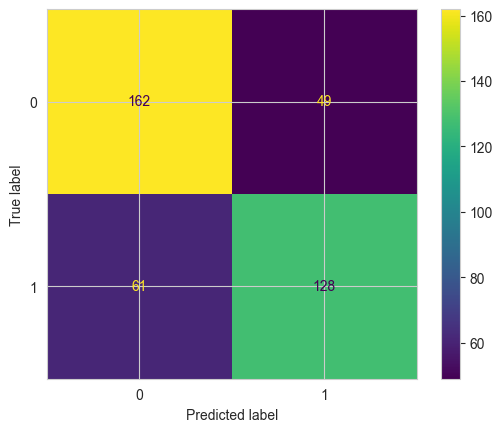

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [50]:
scores = cross_val_score(pipeline, X, y.to_numpy().ravel(), cv=5)
print(f"Средняя точность на кросс-валидации: {scores.mean():.2%}")

Средняя точность на кросс-валидации: 71.45%


knn

In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [81]:
X_columns = list(df_copy.columns)
del X_columns[11]
X = pd.DataFrame(df_copy[X_columns])
y = pd.DataFrame(df_copy[["Chronic_kidney_disease"]])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=200, n_jobs=-1))
])

pipeline.fit(X_train, y_train.to_numpy().ravel())

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True


In [82]:
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность: {accuracy:.2%}")

Точность: 72.50%


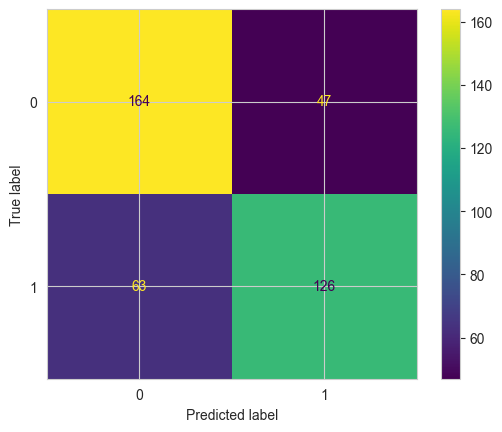

In [83]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [54]:
scores = cross_val_score(pipeline, X, y.to_numpy().ravel(), cv=5)
print(f"Средняя точность на кросс-валидации: {scores.mean():.2%}")

Средняя точность на кросс-валидации: 70.40%


perceptron

In [55]:
from sklearn.neural_network import MLPClassifier

In [77]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ("mlp", MLPClassifier(hidden_layer_sizes=(200, 200), max_iter=2000, random_state=42))
])

pipeline.fit(X_train, y_train.to_numpy().ravel())

,steps,"[('imputer', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(200, ...)"


In [78]:
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность: {accuracy:.2%}")

Точность: 52.75%


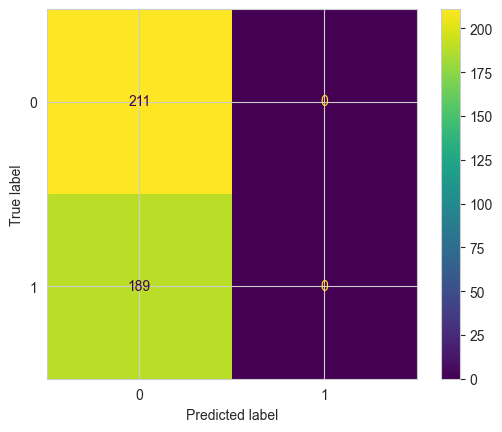

In [79]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [76]:
scores = cross_val_score(pipeline, X, y.to_numpy().ravel(), cv=5)
print(f"Средняя точность на кросс-валидации: {scores.mean():.2%}")

Средняя точность на кросс-валидации: 49.90%


## Сохранение модели

In [38]:
dump(grid_search.best_estimator_, "second_model.pkl")

['second_model.pkl']

In [43]:
saved_model = load("second_model.pkl")

In [44]:
saved_model.predict(X_test)

array([1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,

In [2]:
saved_model = load("model.pkl")

C:\Users\romeow\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator NearestNeighbors from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\romeow\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\romeow\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unp

In [9]:
print(saved_model.named_steps['rf'].feature_names_in_)

['Sex(M/F)' 'Category SBP' 'Category DBP' 'Category BMI' 'Category Pulse'
 'Age(year)']


In [56]:
# 1. Список колонок (именно в том порядке, в котором училась модель)
cols = ['Sex(M/F)', 'Category SBP', 'Category DBP', 'Category BMI', 'Category Pulse', 'Age(year)']

# 2. Твои данные из примера [1, 1, 1, 24, 1, 20] обернутые в список списков [[]]
vals = [[1, 0, 1, 2, 1, 60]]

# 3. Создаем чистый DataFrame
input_df = pd.DataFrame(vals, columns=cols)

# 4. Делаем предсказание
prediction = saved_model.predict(input_df)
print(prediction)

[1]


In [64]:
saved_model.predict([[1, 5, 1, 2, 1, 20]])

C:\Users\romeow\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])